<a href="https://colab.research.google.com/github/Vridhi-Wadhawan/stock-market-anomaly-detection/blob/main/stock_market_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stock Market Anomaly Detection using Isolation Forest

## Project Objective

This project detects unusual movements in IT sector stock prices using an unsupervised machine learning approach.
Isolation Forest is used to identify anomalous return patterns in individual stocks relative to their sector benchmark.

The goal is to demonstrate how machine learning can be combined with financial context to interpret unusual market behaviour.

## Methodology

The analysis follows the steps below:

1. Select a portfolio of major IT sector stocks along with sector and market indices.
2. Collect historical price data using Yahoo Finance.
3. Compute daily log returns and normalize them relative to the sector index.
4. Apply an Isolation Forest model to detect anomalous return patterns.
5. Visualize anomalies and interpret them using real-world financial events.

## Importing Libraries

In [ ]:
# Import Libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import seaborn as sns

# Plotting settings
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

## Portfolio Selection

In [ ]:
# Portfolio Construction
sector_name = "IT"
sector_index = "^CNXIT"  # NIFTY IT Index
market_index = "^NSEI"   # NIFTY 50

# 5 actively traded IT stocks
stock_tickers = ["TCS.NS", "INFY.NS", "LTIM.NS", "PERSISTENT.NS", "COFORGE.NS"]
all_tickers = stock_tickers + [sector_index, market_index]

## Data Collection

In [ ]:
# Data Collection (Last 6 Months)
end_date = pd.Timestamp.today()
start_date = end_date - pd.DateOffset(months=6)

# Download Adjusted Close Prices
data = yf.download(all_tickers, start=start_date, end=end_date)

/tmp/ipython-input-35-1905876545.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(all_tickers, start=start_date, end=end_date)
[*********************100%***********************]  7 of 7 completed


In [ ]:
# Print columns to inspect available data
print(data.columns)

MultiIndex([( 'Close',    'COFORGE.NS'),
            ( 'Close',       'INFY.NS'),
            ( 'Close',       'LTIM.NS'),
            ( 'Close', 'PERSISTENT.NS'),
            ( 'Close',        'TCS.NS'),
            ( 'Close',        '^CNXIT'),
            ( 'Close',         '^NSEI'),
            (  'High',    'COFORGE.NS'),
            (  'High',       'INFY.NS'),
            (  'High',       'LTIM.NS'),
            (  'High', 'PERSISTENT.NS'),
            (  'High',        'TCS.NS'),
            (  'High',        '^CNXIT'),
            (  'High',         '^NSEI'),
            (   'Low',    'COFORGE.NS'),
            (   'Low',       'INFY.NS'),
            (   'Low',       'LTIM.NS'),
            (   'Low', 'PERSISTENT.NS'),
            (   'Low',        'TCS.NS'),
            (   'Low',        '^CNXIT'),
            (   'Low',         '^NSEI'),
            (  'Open',    'COFORGE.NS'),
            (  'Open',       'INFY.NS'),
            (  'Open',       'LTIM.NS'),
            (  '

In [ ]:
data = data.xs('Close', level='Price', axis=1)
data.dropna(inplace=True)
display(data.head())

Ticker,COFORGE.NS,INFY.NS,LTIM.NS,PERSISTENT.NS,TCS.NS,^CNXIT,^NSEI
Date,,,,,,,
2025-01-13,1737.327759,1934.974609,5976.723633,5983.575684,4243.183594,43999.101562,23085.949219
2025-01-14,1714.746948,1913.132080,5700.371582,5860.683105,4185.781250,43061.199219,23176.050781
2025-01-15,1712.940918,1922.598877,5785.254395,6091.069824,4202.146973,43401.250000,23213.199219
2025-01-16,1742.476562,1901.692871,5925.238770,6051.550781,4159.330078,43188.851562,23311.800781
2025-01-17,1724.555664,1790.260742,5837.531738,5941.515137,4087.964600,42032.199219,23203.199219


In [ ]:
# Save the data DataFrame to a CSV file
data.to_csv('stock_data.csv')
print("DataFrame 'data' saved to 'stock_data.csv'")

DataFrame 'data' saved to 'stock_data.csv'


## Return Engineering

### Daily Log Returns

In [ ]:
# Computing Daily Returns to Log
log_returns = np.log(data / data.shift(1)).dropna()
log_returns.head()

Ticker,COFORGE.NS,INFY.NS,LTIM.NS,PERSISTENT.NS,TCS.NS,^CNXIT,^NSEI
Date,,,,,,,
2025-01-14,-0.013083,-0.011352,-0.047341,-0.020752,-0.013620,-0.021547,0.003895
2025-01-15,-0.001054,0.004936,0.014781,0.038558,0.003902,0.007866,0.001602
2025-01-16,0.017096,-0.010933,0.023909,-0.006509,-0.010242,-0.004906,0.004239
2025-01-17,-0.010338,-0.060383,-0.014913,-0.018350,-0.017307,-0.027146,-0.004670
2025-01-20,0.002375,-0.001185,-0.011096,0.021524,-0.011339,0.003814,0.006082


In [ ]:
# Save excess log return data
log_returns.to_csv('log_returns.csv')
print("Log return data saved to 'log_returns.csv'")

Log return data saved to 'log_returns.csv'


### Sector-Normalized Returns

In [ ]:
# Extracting sectoral and market returns
sector_returns = log_returns[sector_index]
market_returns = log_returns[market_index]
# Computeing excess returns over sector
excess_returns = log_returns[stock_tickers].subtract(sector_returns, axis=0)
excess_returns.head()

Ticker,TCS.NS,INFY.NS,LTIM.NS,PERSISTENT.NS,COFORGE.NS
Date,,,,,
2025-01-14,0.007926,0.010194,-0.025794,0.000795,0.008464
2025-01-15,-0.003964,-0.002930,0.006915,0.030692,-0.008920
2025-01-16,-0.005336,-0.006028,0.028814,-0.001603,0.022002
2025-01-17,0.009840,-0.033237,0.012233,0.008796,0.016808
2025-01-20,-0.015152,-0.004999,-0.014910,0.017710,-0.001438


In [ ]:
# Save excess return data
excess_returns.to_csv('excess_returns.csv')
print("Excess return data saved to 'excess_returns.csv'")

Excess return data saved to 'excess_returns.csv'


## Model: Isolation Forest

In [ ]:
# Anomaly Detection using Isolation Forest
anomaly_results = {}
for stock in stock_tickers:
    model = IsolationForest(contamination=0.05, random_state=40)
    model.fit(excess_returns[[stock]])
    preds = model.predict(excess_returns[[stock]])
    anomaly_dates = excess_returns.index[preds == -1]
    anomaly_results[stock] = anomaly_dates
# Displaying Anomaly Dates
    print(f"\n{stock} - Anomalies Detected on:")
    for date in anomaly_dates:
      print(f" - {date.strftime('%Y-%m-%d')}")


TCS.NS - Anomalies Detected on:
 - 2025-01-23
 - 2025-01-27
 - 2025-02-18
 - 2025-03-04
 - 2025-03-06
 - 2025-04-07
 - 2025-04-21

INFY.NS - Anomalies Detected on:
 - 2025-01-17
 - 2025-02-11
 - 2025-03-10
 - 2025-03-11
 - 2025-03-21
 - 2025-05-12
 - 2025-05-13

LTIM.NS - Anomalies Detected on:
 - 2025-01-14
 - 2025-01-16
 - 2025-02-18
 - 2025-03-03
 - 2025-03-17
 - 2025-03-21
 - 2025-04-11

PERSISTENT.NS - Anomalies Detected on:
 - 2025-01-22
 - 2025-01-23
 - 2025-01-29
 - 2025-02-10
 - 2025-02-18
 - 2025-04-01
 - 2025-04-03

COFORGE.NS - Anomalies Detected on:
 - 2025-01-23
 - 2025-02-21
 - 2025-02-24
 - 2025-03-05
 - 2025-03-19
 - 2025-04-03
 - 2025-04-04


## Anomaly Visualization

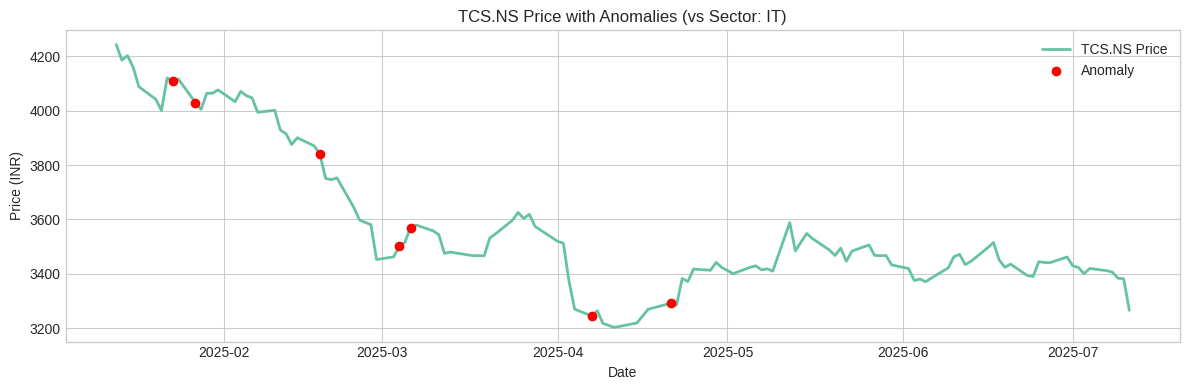

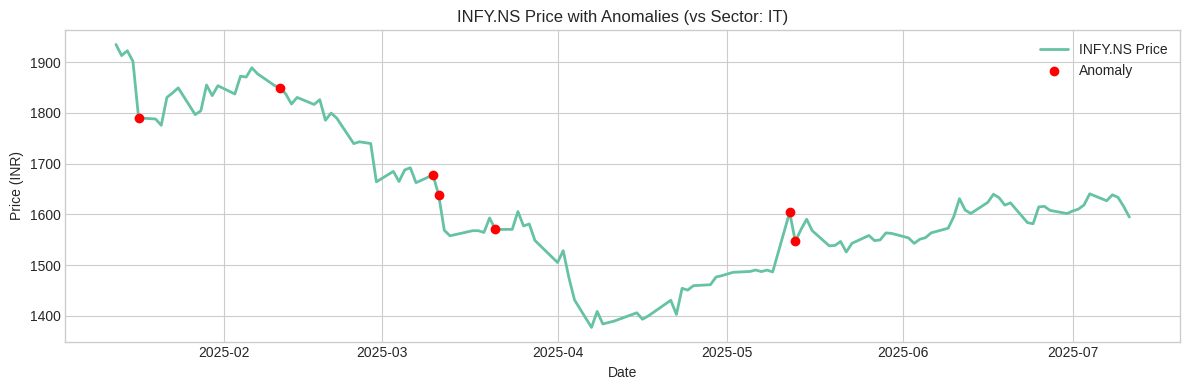

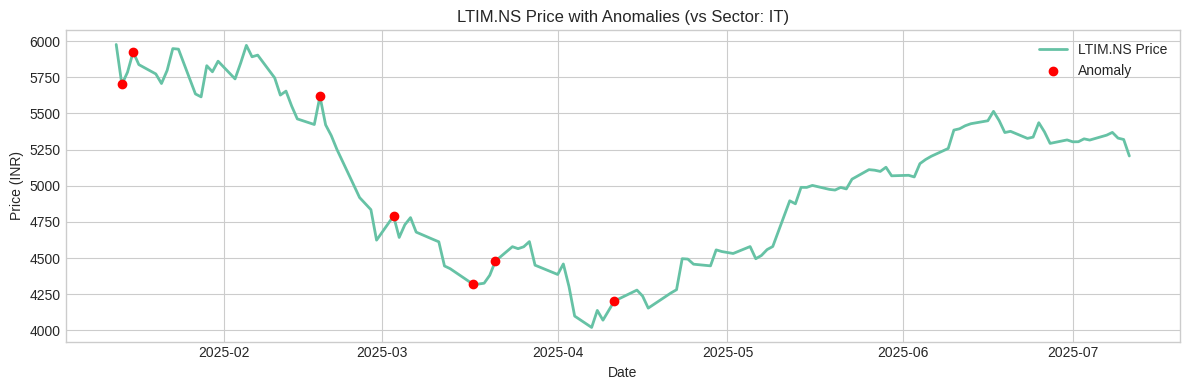

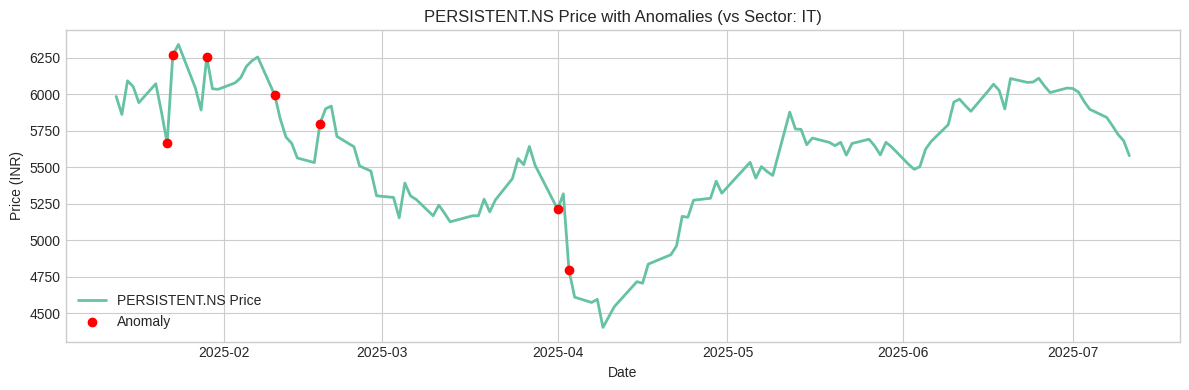

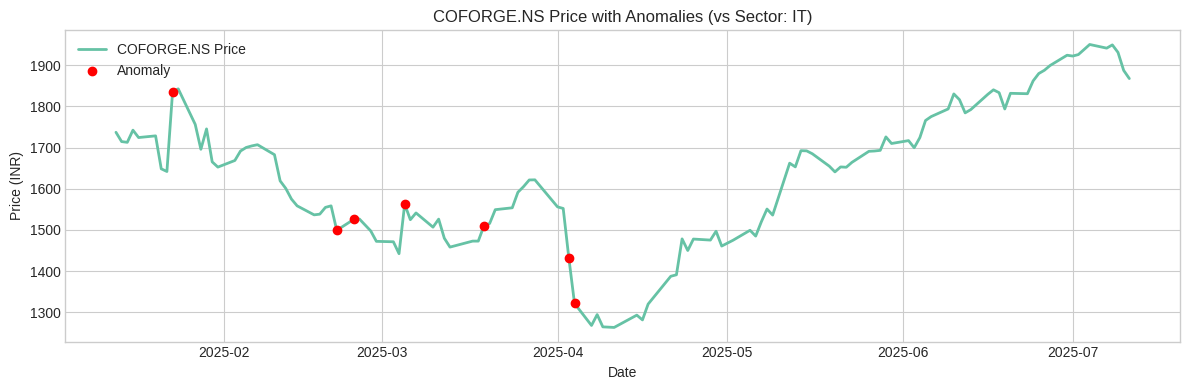

In [ ]:
# Visualize Prices with Anomalies
for stock in stock_tickers:
    plt.figure(figsize=(12, 4))
    plt.plot(data[stock], label=f"{stock} Price", linewidth=2)
    plt.scatter(anomaly_results[stock], data.loc[anomaly_results[stock], stock],
                color='red', label='Anomaly', zorder=5)
    plt.title(f"{stock} Price with Anomalies (vs Sector: {sector_name})")
    plt.xlabel("Date")
    plt.ylabel("Price (INR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpreting Detected Anomalies

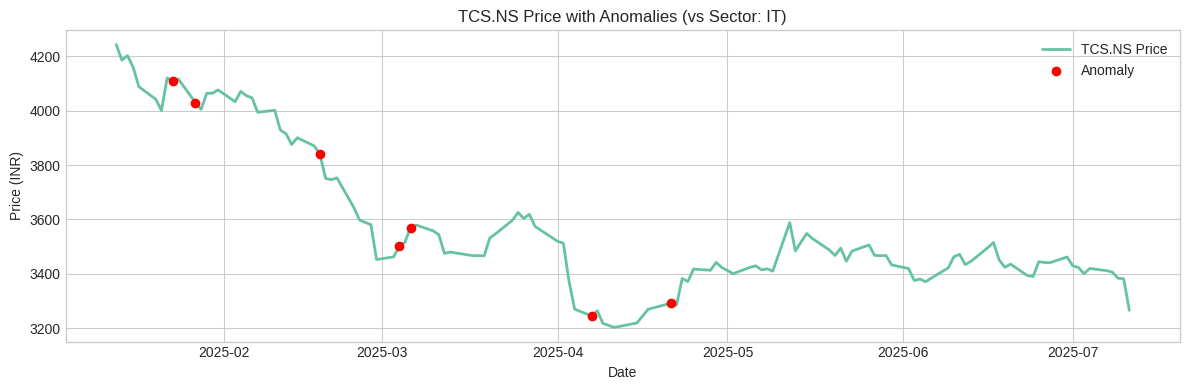

In [ ]:
# Visualize Prices with Anomalies for TCS
for stock in stock_tickers:
  if stock == "TCS.NS":
    plt.figure(figsize=(12, 4))
    plt.plot(data[stock], label=f"{stock} Price", linewidth=2)
    plt.scatter(anomaly_results[stock], data.loc[anomaly_results[stock], stock],
                color='red', label='Anomaly', zorder=5)
    plt.title(f"{stock} Price with Anomalies (vs Sector: {sector_name})")
    plt.xlabel("Date")
    plt.ylabel("Price (INR)")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Anomaly 1: TCS Share Price Fluctuation**

Our model flagged two sharp moves in TCS shares, each tied to quarterly earnings news. On 23 January 2025, TCS stock spiked unusually after markets digested the Q3 FY25 report released on 9 January:  

* Revenue: ₹63,973 crore (+5.6% YoY; +4.5% in CC)  
* Net Income: ₹12,380 crore (+5.5% YoY)  
* Operating Margin: 24.5%  
* Dividend: ₹76 per share (includes ₹66 special)

Management highlighted broad-based growth—India +70.2%, Regional Markets +40.9%—and growing momentum in AI and GenAI services. The combination of better-than-expected profits, industry-leading margins, and a special dividend drove trading volume well above normal.

By February, TCS stock began to dip following news of new tariffs imposed by Donald Trump, specifically targeting semiconductors. This raised concerns about supply chain costs and future demand for IT services, hurting investor sentiment.

On 7 April 2025, TCS’s share price fell again— dropping over 5% during the day and ending 3.43% lower. This was unusual because TCS normally has small and steady price changes. A few days later, on 10 April, TCS announced its Q4 FY25 results:

* Revenue: ₹64,479 crore (+5.3% YoY)  
* Net Profit: ₹12,224 crore (−1.6% YoY)  
* Operating Margin: 24.2%; Net Margin: 19.0%  
* Dividend Proposal: ₹30 per share (vs. ₹76 last quarter)  

Even though TCS crossed the $30 billion revenue milestone, net profit dipped and margins compressed slightly. The sharp cut in dividend payout and U.S. tariffs on IT services caught investors off guard and played a major role in determining investor sentiment.

This series of events shows how a strong quarter can set high expectations, and when even a small miss follows — especially in profit or dividends — a normally low-volatility stock like TCS can see significant price swings. External factors, like political developments, only add to the pressure.

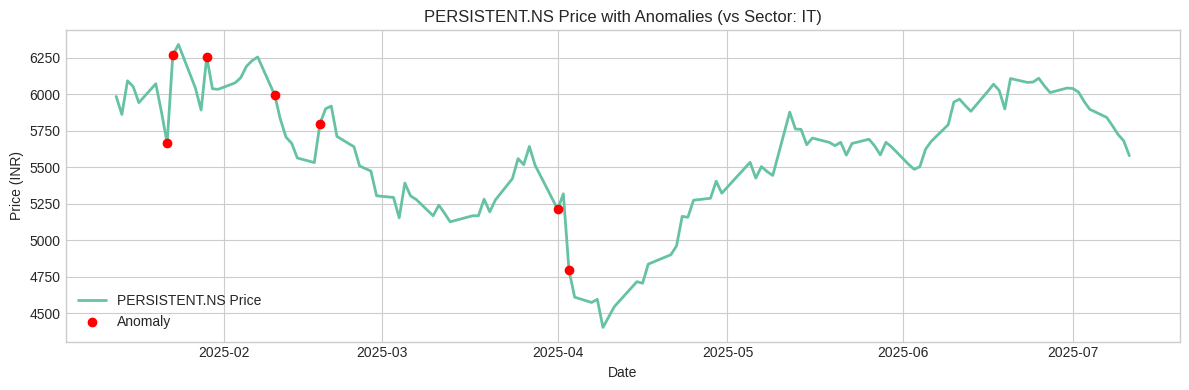

In [ ]:
# Visualize Prices with Anomalies for PERSISTENT
for stock in stock_tickers:
    if stock == "PERSISTENT.NS":
        plt.figure(figsize=(12, 4))
        plt.plot(data[stock], label=f"{stock} Price", linewidth=2)
        plt.scatter(anomaly_results[stock], data.loc[anomaly_results[stock], stock],
                    color='red', label='Anomaly', zorder=5)
        plt.title(f"{stock} Price with Anomalies (vs Sector: {sector_name})")
        plt.xlabel("Date")
        plt.ylabel("Price (INR)")
        plt.legend()
        plt.tight_layout()
        plt.show()

**Anomaly 2: Persistent Stock Surge (Q4 & Q3 Earnings)**

Our model flagged two sharp moves in Persistent shares, each tied to quarterly earnings news. On 22 January 2025, Persistent showed an unusual price movement, flagged by our model. This date aligns exactly with the company’s Q3 FY25 earnings release which reported the following:

* Revenue: ₹30,622.8 million (US $360.2 million), up 22.6% YoY and +5.7% QoQ  
* EBITDA: ₹5,378.4 million (17.6% margin, +11.9% YoY)  
* Declared an interim dividend of ₹20 per share  

The report also highlighted its AI-driven, platform-based strategy — including 20+ new patents for its SASVA platform — along with several industry awards. This strong earnings report, along with expanding margins and a dividend announcement, sparked high investor interest. The trading activity on this day was well above the stock’s usual range. This is an example of how a strong earnings "beat" combined with shareholder-friendly actions (like dividends) can drive sharp stock price changes — even for a typically stable stock.

On 6 February 2025, Persistent stock jumped nearly 20% after reporting strong Q4 FY24 earnings, which was a big change from its usual price movements. Persistent reported record-breaking results as it reported the following highlights:

* Revenue: 1.15 billion dollars (+18% YoY), its first billion-dollar quarter
* Monthly Active Users: 553 million (+11% YoY)
* Adjusted EBITDA Margin: 41%
* Announced a $2 billion stock buyback

CEO Bill Ready called 2024 a “banner year,” and investors were encouraged by the strong growth, improved ad results, due to AI tools, and solid profitability.

Investors were impressed by strong user growth, especially in international markets. Persistent's AI-powered ad tools helped advertisers get better results, boosting platform value. The company also announced a 2 billion dollars stock buyback, which increased confidence in future performance.

Although political factors like Trump’s newly imposed tariffs also played a role in determining market behavior and the general negative sentiment observed in February, Persistent stock spike was largely driven by two strong quarters of financial and operational performance.This showed how positive earnings surprises and confident guidance can lead to sharp stock movements. Persistent's growth in users, ad performance, and AI investment all signaled strong potential — and that encouraged investors to jump in.

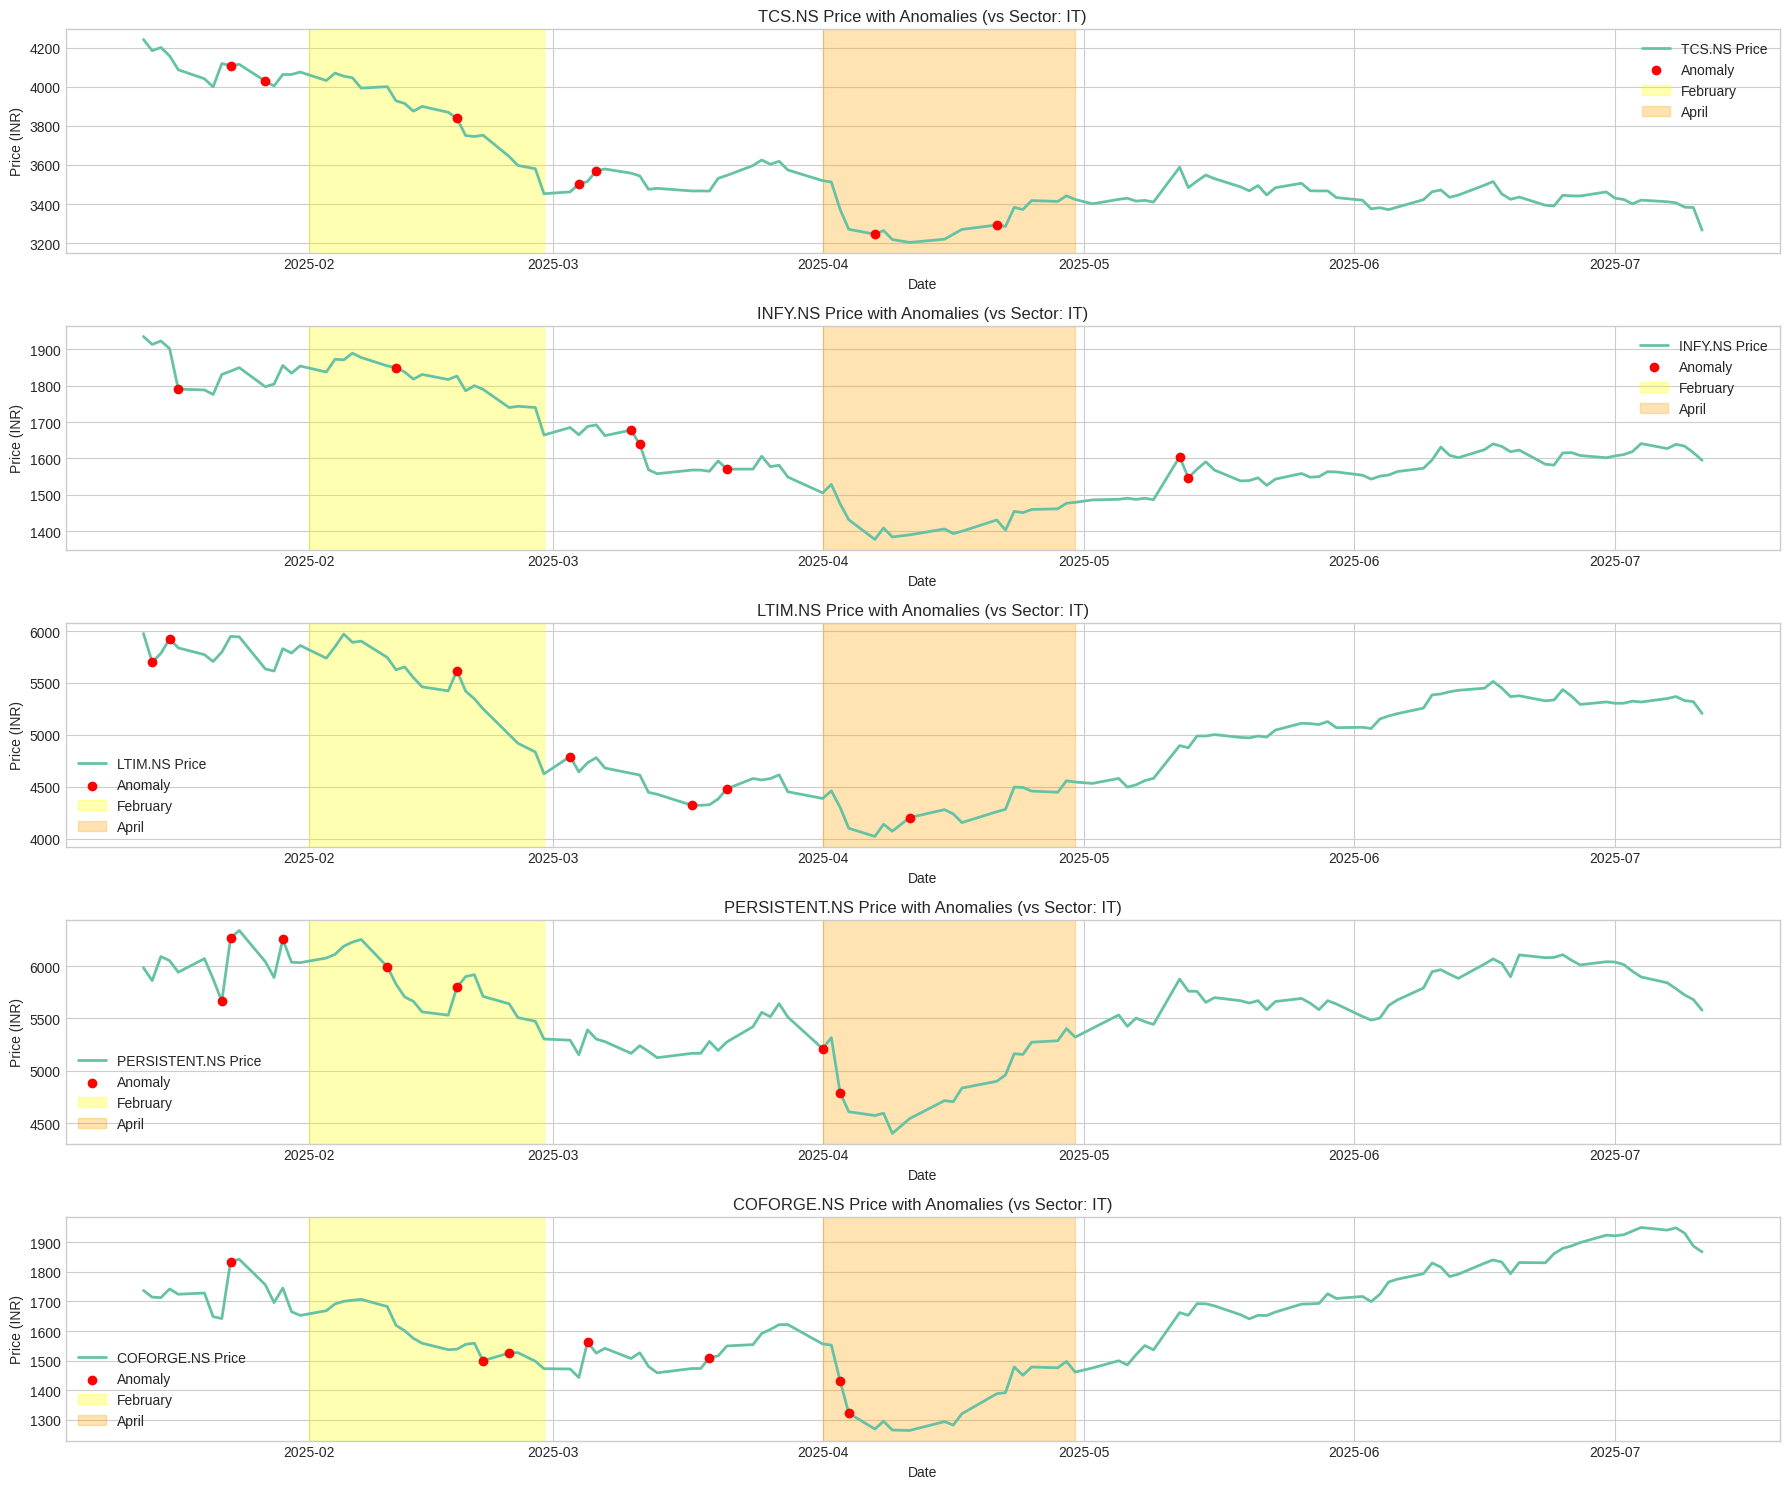

In [ ]:
# Visualize Prices with Anomalies for all stocks, highlighting February and April
num_stocks = len(stock_tickers)
# Adjust figsize to accommodate all plots horizontally
plt.figure(figsize=(18, 3 * num_stocks))
for i, stock in enumerate(stock_tickers):
    # Create a subplot for each stock
    plt.subplot(num_stocks, 1, i + 1)

    plt.plot(data[stock], label=f"{stock} Price", linewidth=2)
    plt.scatter(anomaly_results[stock], data.loc[anomaly_results[stock], stock],
                color='red', label='Anomaly', zorder=5)

    # Highlight February and April
    feb_start = pd.Timestamp(start_date.year, 2, 1)
    feb_end = pd.Timestamp(start_date.year, 3, 1) - pd.Timedelta(days=1)
    apr_start = pd.Timestamp(start_date.year, 4, 1)
    apr_end = pd.Timestamp(start_date.year, 5, 1) - pd.Timedelta(days=1)

    # Adjust year for highlighting based on the start_date of the data
    data_start_year = data.index.min().year
    feb_start = pd.Timestamp(data_start_year, 2, 1)
    feb_end = pd.Timestamp(data_start_year, 3, 1) - pd.Timedelta(days=1)
    apr_start = pd.Timestamp(data_start_year, 4, 1)
    apr_end = pd.Timestamp(data_start_year, 5, 1) - pd.Timedelta(days=1)


    plt.axvspan(feb_start, feb_end, color='yellow', alpha=0.3, label='February')
    plt.axvspan(apr_start, apr_end, color='orange', alpha=0.3, label='April')


    plt.title(f"{stock} Price with Anomalies (vs Sector: {sector_name})")
    plt.xlabel("Date")
    plt.ylabel("Price (INR)")
    plt.legend()
# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

**Anomaly: General Market Dip After Tariff News**

On 18th February 2025, markets fell after President Trump announced plans for 25% tariffs on automobiles, semiconductors, and pharmaceuticals. The proposed tariffs on semiconductors worried investors because it could raise the costs in the IT and electronics industry while slowing down innovation and demand and thereby disrupting the global supply chains.

Trump mentioned the tariffs might begin on April 2, causing fears of a global trade war. Investors reacted by selling stocks, especially in sectors likely to be affected. In our portfolio, TCS, LTIM, and Persistent Systems all saw price drops after the news and highlighted 18th February as an anomaly date. Further on visual inspection of the graphs we do see a downward trend near the announcement in February and the continued negative sentiment in the beginning of April. Thus showing the dips.

We have highlighted the announcement in February, showing the negative market sentiment and the tariffs implementation in April beginning showing a sharp fall in all the stocks in our portfolio.  

This showed how major political announcements — even before they are enforced — can quickly affect the stock market by increasing uncertainty and reducing investor confidence.

## Key Insights

Market anomalies are not just statistical outliers — they often reflect investor reactions to financial events, earnings surprises, or macroeconomic developments.

By combining machine learning based anomaly detection with contextual financial analysis, we can move beyond identifying unusual data points to understanding the underlying drivers of market behaviour.